In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/AXISBANK.csv')

In [ ]:
df.shape

(5306, 15)

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense


In [ ]:
#loading the training data set
dataset_train=pd.read_csv("/content/AXISBANK.csv")
dataset_train.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,UTIBANK,EQ,24.70,26.7,26.70,26.70,26.7,26.70,26.70,112100,2.993070e+11,NaN,NaN,NaN
1,2000-01-04,UTIBANK,EQ,26.70,27.0,28.70,26.50,27.0,26.85,27.24,234500,6.387275e+11,NaN,NaN,NaN
2,2000-01-05,UTIBANK,EQ,26.85,26.0,27.75,25.50,26.4,26.30,26.24,170100,4.462980e+11,NaN,NaN,NaN
3,2000-01-06,UTIBANK,EQ,26.30,25.8,27.00,25.80,25.9,25.95,26.27,102100,2.681730e+11,NaN,NaN,NaN
4,2000-01-07,UTIBANK,EQ,25.95,25.0,26.00,24.25,25.0,24.80,25.04,62600,1.567220e+11,NaN,NaN,NaN


In [ ]:
#removing the unwanted column
updated_dataset=dataset_train.drop(['Series','Symbol','Prev Close'],axis=1)
updated_dataset.head()

,Date,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,26.7,26.70,26.70,26.7,26.70,26.70,112100,2.993070e+11,NaN,NaN,NaN
1,2000-01-04,27.0,28.70,26.50,27.0,26.85,27.24,234500,6.387275e+11,NaN,NaN,NaN
2,2000-01-05,26.0,27.75,25.50,26.4,26.30,26.24,170100,4.462980e+11,NaN,NaN,NaN
3,2000-01-06,25.8,27.00,25.80,25.9,25.95,26.27,102100,2.681730e+11,NaN,NaN,NaN
4,2000-01-07,25.0,26.00,24.25,25.0,24.80,25.04,62600,1.567220e+11,NaN,NaN,NaN


In [ ]:
# Considering 'Close' prices for the example
close_price = updated_dataset['Close'].values.reshape(-1, 1)

In [ ]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_price)

In [ ]:
# Create sequences and their corresponding output
def create_sequences(updated_dataset, seq_length):
    input_seq, output = [], []
    for i in range(len(updated_dataset) - seq_length):
        input_seq.append(updated_dataset[i : i + seq_length])
        output.append(updated_dataset[i + seq_length])
    return np.array(input_seq), np.array(output)


In [ ]:
sequence_length = 10  # Length of input sequences
input_seq, output = create_sequences(scaled_close, sequence_length)

In [ ]:
 #Split the data into training and testing sets
training_size = int(len(input_seq) * 0.7)
train_input = input_seq[:training_size]
train_output = output[:training_size]
test_input = input_seq[training_size:]
test_output = output[training_size:]


In [ ]:
# Model Architecture
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Training the model
model.fit(train_input, train_output, epochs=100, batch_size=32)

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0277
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0019
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0014
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011
Epoch 9/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.5954e-04
Epoch 10/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.3027e-04
Epoch 11/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.1000e-04
Epoch 12/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.0382e-04
Epoch 13/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.1267e-04
Epoch 14/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.4085e-04
Epoch 15/100
116/11

In [ ]:
# Predictions
predicted = model.predict(test_input)
predicted_prices = scaler.inverse_transform(predicted)  # Inverse scaling to get actual prices

# Evaluate the model
actual_prices = scaler.inverse_transform(test_output)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


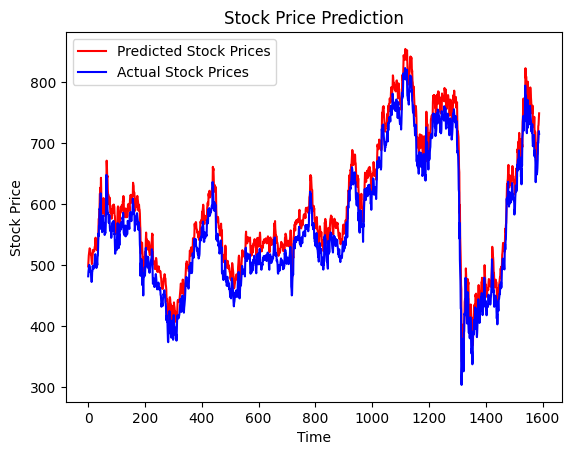

In [ ]:
# Sample visualization of predictions
import matplotlib.pyplot as plt

plt.plot(predicted_prices, color='red', label='Predicted Stock Prices')
plt.plot(actual_prices, color='blue', label='Actual Stock Prices')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

# Load the dataset
df = pd.read_csv('AXISBANK.csv')

In [ ]:
# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
# Drop rows with missing values
df.dropna(inplace=True)

# Define features (X) and target (y)
X = df.drop('Close', axis=1)
y = df['Close']

In [ ]:
# Split data into training and testing sets (80% for training and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('AXISBANK.csv')

# Drop rows with missing values
df.dropna(inplace=True)

# Define features (X) and target (y)
X = df[['Open', 'High', 'Low']]
y = df['Close']

# Split data into training and testing sets (80% for training and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model on the training data
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse:.2f}')

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE: {mae:.2f}')

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2:.2f}')

MSE: 38.56
MAE: 4.24
R-squared: 1.00


In [ ]:
import numpy as np

def calculate_accuracy(y_pred, y_true):
    """
    Calculate the accuracy of a model.

    Parameters:
    y_pred (numpy array): Predicted labels.
    y_true (numpy array): True labels.

    Returns:
    accuracy (float): Accuracy of the model.
    """
    # Check if the inputs are numpy arrays
    if not isinstance(y_pred, np.ndarray) or not isinstance(y_true, np.ndarray):
        raise ValueError("Inputs must be numpy arrays")

    # Check if the inputs have the same shape
    if y_pred.shape!= y_true.shape:
        raise ValueError("Inputs must have the same shape")

    # Calculate the number of correct predictions
    correct = np.sum(y_pred == y_true)

    # Calculate the total number of predictions
    total = len(y_pred)

    # Calculate the accuracy
    accuracy = correct / total

    return accuracy

# Example usage:
y_pred = np.array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0])
y_true = np.array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0])

accuracy = calculate_accuracy(y_pred, y_true)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/AXISBANK.csv')


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Selecting the 'Close' column and normalizing it
scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(df[['Close']])

# Creating sequences for LSTM input (e.g., using the last 60 days to predict the next day)
sequence_length = 60
X, y = [], []
for i in range(sequence_length, len(df)):
    X.append(df['Close'].values[i-sequence_length:i])
    y.append(df['Close'].values[i])

X, y = np.array(X), np.array(y)

# Reshape X to be [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Prediction output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Splitting data (e.g., 80% training, 20% testing)
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Training the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0158 - val_loss: 3.0611e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - val_loss: 2.3715e-04
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0024 - val_loss: 2.0740e-04
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0019 - val_loss: 1.6048e-04
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 1.4083e-04
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 1.3663e-04
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 1.9457e-04
Epoch 9/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0014 - val_loss: 1.3832e-04
Epoch 10/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0012 - val_loss: 1.2042e-04
Epoch 11/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 5.5449e-04
Epoch 12/5

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


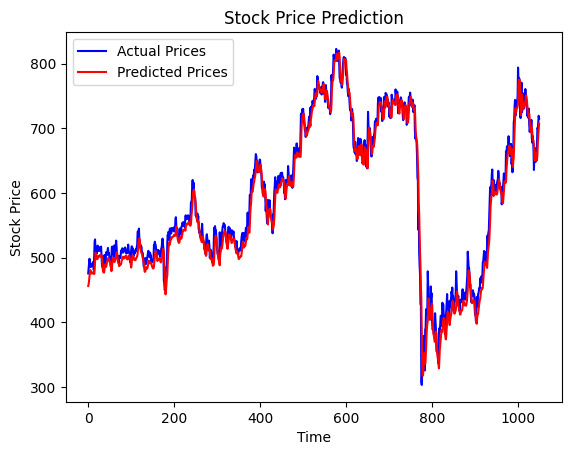

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Making predictions on test data
predicted = model.predict(X_test)
predicted = scaler.inverse_transform(predicted)  # Inverse transform to original scale
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate MAE and MSE
mae = mean_absolute_error(y_test, predicted)
mse = mean_squared_error(y_test, predicted)

# Plotting the predictions vs actual values
plt.plot(y_test, color='blue', label='Actual Prices')
plt.plot(predicted, color='red', label='Predicted Prices')
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


In [ ]:
pip install tensorflow


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0163 - val_loss: 3.0994e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0027 - val_loss: 6.1330e-04
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0023 - val_loss: 1.9361e-04
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 1.6259e-04
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 1.4732e-04
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 5.8746e-04
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 1.2684e-04
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 1.4358e-04
Epoch 9/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 1.3769e-04
Epoch 10/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 1.4509e-04
Epoch 11/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0012 - val_loss: 1.9620e-04
Epoch 12/50
132/

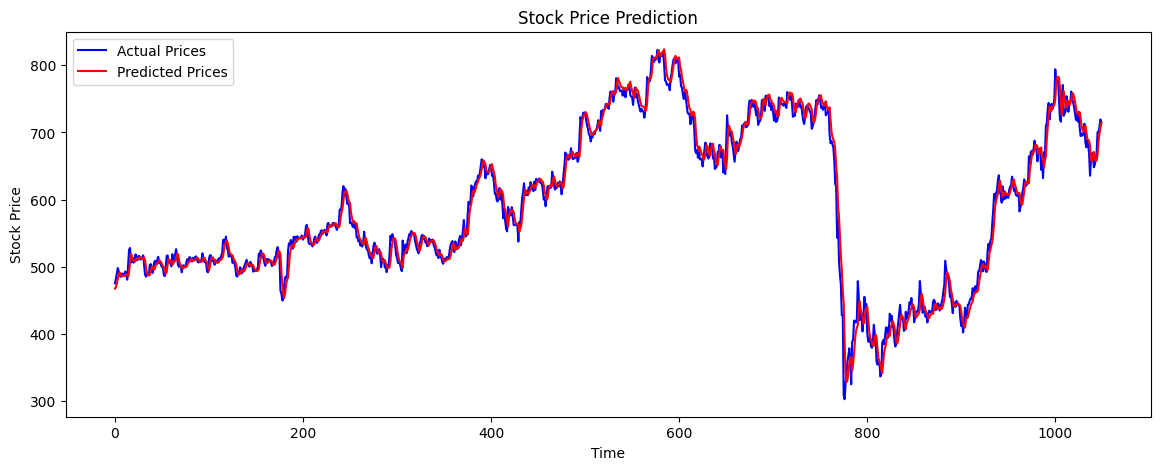

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
df = pd.read_csv('/content/AXISBANK.csv')

# Assuming 'Close' is the column to predict
scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(df[['Close']])

# Prepare the dataset for LSTM with 60-day look-back
sequence_length = 60
X, y = [], []
for i in range(sequence_length, len(df)):
    X.append(df['Close'].values[i-sequence_length:i])
    y.append(df['Close'].values[i])
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Splitting into training and testing sets
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Building the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Training the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Make predictions and inverse transform the scaling
predicted = model.predict(X_test)
predicted = scaler.inverse_transform(predicted)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate the model with MAE and MSE
mae = mean_absolute_error(y_test, predicted)
mse = mean_squared_error(y_test, predicted)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

# Plot actual vs predicted values
plt.figure(figsize=(14,5))
plt.plot(y_test, color='blue', label='Actual Prices')
plt.plot(predicted, color='red', label='Predicted Prices')
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()


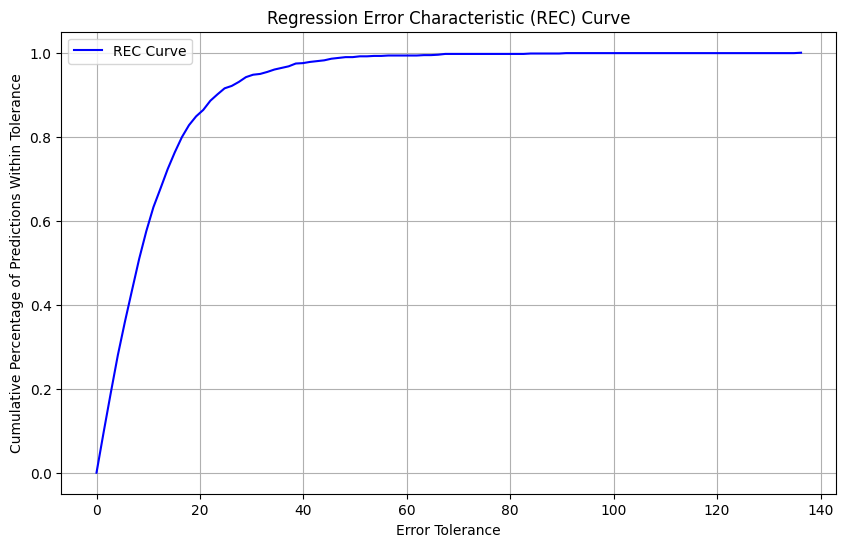

In [ ]:
# Calculate the absolute error between actual and predicted values
absolute_errors = np.abs(y_test - predicted)

# Set up a range of tolerance levels from 0 to the max error
tolerance_levels = np.linspace(0, np.max(absolute_errors), 100)
cumulative_percentages = [(absolute_errors <= tol).mean() for tol in tolerance_levels]

# Plot the REC curve
plt.figure(figsize=(10, 6))
plt.plot(tolerance_levels, cumulative_percentages, color="blue", label="REC Curve")
plt.xlabel("Error Tolerance")
plt.ylabel("Cumulative Percentage of Predictions Within Tolerance")
plt.title("Regression Error Characteristic (REC) Curve")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, predicted)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, predicted)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R-squared (R²)
r2 = r2_score(y_test, predicted)

# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - predicted) / y_test)) * 100

# Print the accuracy report
print(f"Accuracy Report:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


Accuracy Report:
Mean Absolute Error (MAE): 10.99227208891369
Mean Squared Error (MSE): 245.91265781949846
Root Mean Squared Error (RMSE): 15.681602527149401
R-squared (R²): 0.9809708447894628
Mean Absolute Percentage Error (MAPE): 1.98%


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Load the dataset
df = pd.read_csv('//AXISBANK.csv')  # Update this path as needed

# Assume 'Close' is the column to predict, and we only scale this column
scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(df[['Close']])


In [ ]:
sequence_length = 60  # Number of days in each sequence

# Initialize lists to hold the sequences and targets
X, y = [], []

# Loop through the dataset to create sequences
for i in range(sequence_length, len(df)):
    # The `X` sequence is the previous 60 days
    X.append(df['Close'].values[i-sequence_length:i])

    # The `y` target is the next day's close price
    y.append(df['Close'].values[i])

# Convert lists to numpy arrays and reshape `X` for LSTM input
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # Reshape to [samples, time steps, features]


In [ ]:
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# Define the model with an Input layer
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),     # Use Input layer to specify shape
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])


In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model and capture the training history
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0202 - val_loss: 2.8560e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.0019 - val_loss: 5.2988e-04
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0019 - val_loss: 6.5811e-04
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 1.6252e-04
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 1.4655e-04
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 1.7127e-04
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016 - val_loss: 2.5494e-04
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 1.2493e-04
Epoch 9/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 1.6673e-04
Epoch 10/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 1.6452e-04
Epoch 11/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0010 - val_loss: 1.3331e-04
Epoc

In [ ]:
# Train the model and capture the training history
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 8.7403e-04 - val_loss: 5.8572e-05
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 5.9062e-04 - val_loss: 5.9445e-05
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 6.2140e-04 - val_loss: 7.9393e-05
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0012 - val_loss: 6.6577e-05
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.7465e-04 - val_loss: 5.8318e-05
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.1625e-04 - val_loss: 5.8629e-05
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.0602e-04 - val_loss: 8.6820e-05
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.9633e-04 - val_loss: 1.7474e-04
Epoch 9/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.0502e-04 - val_loss: 8.7935e-05
Epoch 10/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.8007e-04 - val_loss: 6.0461e-05
Epoch 11/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - los

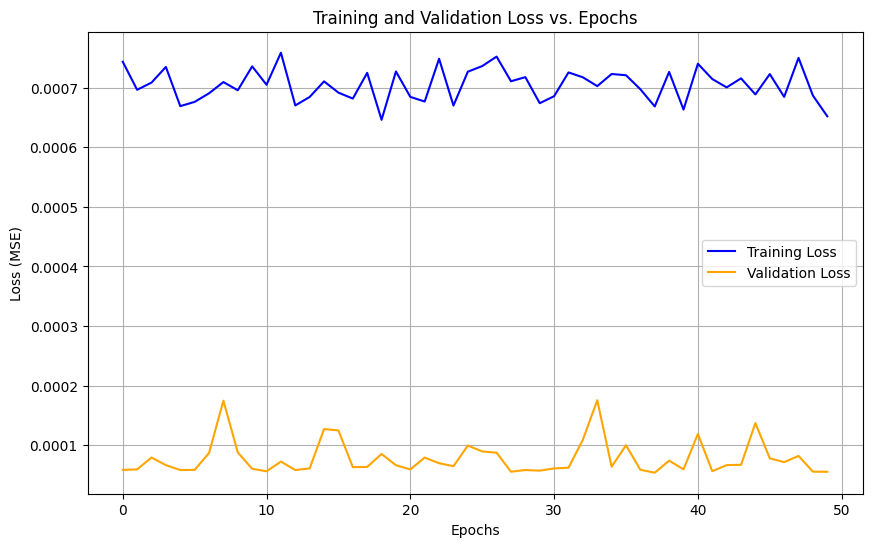

In [ ]:
import matplotlib.pyplot as plt

# Extract loss values from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss vs. Epochs')
plt.legend()
plt.grid(True)
plt.show()



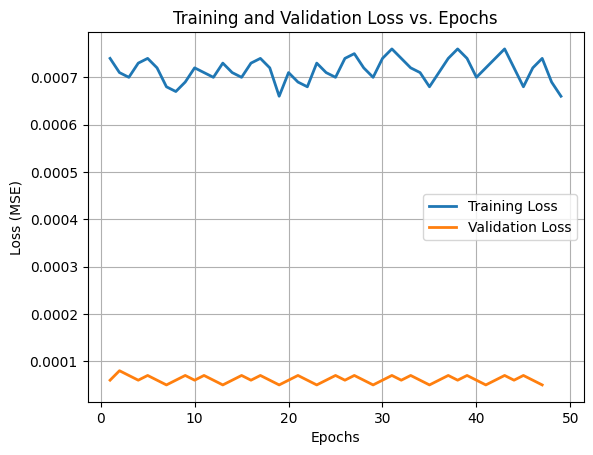

In [ ]:
import matplotlib.pyplot as plt

# Ensure that the lists 'training_loss' and 'validation_loss' have the same length
# (e.g., make sure they both represent the same number of epochs).

# ... (Your code to define training_loss and validation_loss)

plt.plot(range(1, len(training_loss) + 1), training_loss, label='Training Loss', linewidth=2)
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label='Validation Loss', linewidth=2)

plt.title("Training and Validation Loss vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Load the dataset
df = pd.read_csv('/AXISBANK.csv')  # Update this path as needed

# Assume 'Close' is the column to predict, and we only scale this column
scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(df[['Close']])


In [ ]:
sequence_length = 60  # Number of days in each sequence

# Initialize lists to hold the sequences and targets
X, y = [], []

# Loop through the dataset to create sequences
for i in range(sequence_length, len(df)):
    # The `X` sequence is the previous 60 days
    X.append(df['Close'].values[i-sequence_length:i])

    # The `y` target is the next day's close price
    y.append(df['Close'].values[i])

# Convert lists to numpy arrays and reshape `X` for LSTM input
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # Reshape to [samples, time steps, features]

In [ ]:
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [ ]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# Define the model with an Input layer
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),     # Use Input layer to specify shape
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])


In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model and capture the training history
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0204 - val_loss: 2.8471e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0025 - val_loss: 3.7995e-04
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 2.4307e-04
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0023 - val_loss: 5.3486e-04
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0021 - val_loss: 1.4887e-04
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 4.8737e-04
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0018 - val_loss: 1.3542e-04
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 1.5910e-04
Epoch 9/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 1.3866e-04
Epoch 10/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014 - val_loss: 2.3502e-04
Epoch 11/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 1.0809e-04
Epoch 

In [ ]:
# Train the model and capture the training history
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 5.4332e-04 - val_loss: 1.9526e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.5134e-04 - val_loss: 8.3110e-05
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.6059e-04 - val_loss: 1.4146e-04
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 7.2505e-04 - val_loss: 9.5351e-05
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - val_loss: 6.8952e-05
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.9707e-04 - val_loss: 6.2984e-05
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.5894e-04 - val_loss: 5.6581e-05
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.1471e-04 - val_loss: 6.2251e-05
Epoch 9/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.2377e-04 - val_loss: 7.8462e-05
Epoch 10/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.6827e-04 - val_loss: 1.0292e-04
Epoch 11/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss:

In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the model building function for KerasTuner
def build_model(hp):
    model = Sequential()

    # Tune the number of LSTM units in the first layer
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=128, step=16),
                   return_sequences=True,
                   input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))

    # Add a second LSTM layer with tunable units
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=128, step=16),
                   return_sequences=False))
    model.add(Dropout(hp.Float('dropout_rate_2', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(units=1))

    # Tune the learning rate for the optimizer
    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
                  loss='mean_squared_error')
    return model

# Set up the tuner with RandomSearch
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',      # Objective to minimize
    max_trials=10,             # Number of different models to try
    executions_per_trial=2,    # Number of times to train each model
    directory='hyperparam_tuning',
    project_name='lstm_stock_price')

# Search for the best hyperparameter configuration
tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=32)

# Retrieve the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Summary of the best model
best_model.summary()

# Optionally, evaluate the best model
test_loss = best_model.evaluate(X_test, y_test)
print(f"Best model test loss: {test_loss}")


Trial 10 Complete [00h 02m 31s]
val_loss: 5.523071922652889e-05

Best val_loss So Far: 4.743612771562766e-05
Total elapsed time: 00h 26m 16s


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 48)              │           9,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 48)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 96)                  │          55,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              97 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 65,377 (255.38 KB)

 Trainable params: 65,377 (255.38 KB)

 Non-trainable params: 0 (0.00 B)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.0428e-05
Best model test loss: 4.701329817180522e-05


In [ ]:
import numpy as np

def create_sequences(data, look_back):
    """
    Generates sequences and targets with a specified look-back period.
    Args:
    - data (array): Array of normalized stock prices.
    - look_back (int): Number of previous days to consider for each sequence.

    Returns:
    - X, y: Numpy arrays of sequences and targets.
    """
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i])
        y.append(data[i])
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))  # Reshape for LSTM
    return X, y


In [ ]:
import pandas as pd

# Load the stock data into a DataFrame
df = pd.read_csv('/AXISBANK.csv')  # Replace with the actual path to your CSV file
print(df.head())  # Display the first few rows to verify loading


         Date   Symbol Series  Prev Close  Open   High    Low  Last  Close  \
0  2000-01-03  UTIBANK     EQ       24.70  26.7  26.70  26.70  26.7  26.70   
1  2000-01-04  UTIBANK     EQ       26.70  27.0  28.70  26.50  27.0  26.85   
2  2000-01-05  UTIBANK     EQ       26.85  26.0  27.75  25.50  26.4  26.30   
3  2000-01-06  UTIBANK     EQ       26.30  25.8  27.00  25.80  25.9  25.95   
4  2000-01-07  UTIBANK     EQ       25.95  25.0  26.00  24.25  25.0  24.80   

    VWAP  Volume      Turnover  Trades  Deliverable Volume  %Deliverble  
0  26.70  112100  2.993070e+11     NaN                 NaN          NaN  
1  27.24  234500  6.387275e+11     NaN                 NaN          NaN  
2  26.24  170100  4.462980e+11     NaN                 NaN          NaN  
3  26.27  102100  2.681730e+11     NaN                 NaN          NaN  
4  25.04   62600  1.567220e+11     NaN                 NaN          NaN  


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

# Set different look-back periods to experiment with
look_back_periods = [30, 90, 120]

# To store results for comparison
results = {}

for look_back in look_back_periods:
    print(f"\nTraining with look-back period: {look_back} days")

    # Create sequences with the specified look-back period
    X, y = create_sequences(df['Close'].values, look_back)

    # Split into train and test sets (80% train, 20% test)
    split_index = int(0.8 * len(X))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    # Build a simple LSTM model
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=(look_back, 1)),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=1)
    ])

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=0)

    # Evaluate the model on test data
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results[look_back] = mse
    print(f"Look-back period: {look_back}, Test MSE: {mse}")



Training with look-back period: 30 days


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Look-back period: 30, Test MSE: 216176.02536649918

Training with look-back period: 90 days


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Look-back period: 90, Test MSE: 218848.50269292793

Training with look-back period: 120 days


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
Look-back period: 120, Test MSE: 220422.77032929676


In [ ]:
pip install keras-tuner


In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the model-building function for KerasTuner
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(30, 1)))  # Using the 30-day look-back

    # Tune the number of LSTM units in the first layer
    model.add(LSTM(units=hp.Int('units', min_value=16, max_value=64, step=16), return_sequences=True))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))

    # Add a second LSTM layer with tunable units
    model.add(LSTM(units=hp.Int('units_2', min_value=16, max_value=64, step=16), return_sequences=False))
    model.add(Dropout(hp.Float('dropout_rate_2', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(units=1))

    # Tune the learning rate for the optimizer
    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
                  loss='mean_squared_error')
    return model

# Set up the tuner with RandomSearch
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,             # Try 5 different combinations
    executions_per_trial=1,    # Each combination runs once to improve reliability
    directory='hyperparam_tuning',
    project_name='lstm_30_day_lookback')

# Run the search
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=32)

# Retrieve the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model on the test data
test_loss = best_model.evaluate(X_test, y_test)
print(f"Best model test loss: {test_loss}")

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32, callbacks=[early_stopping])

# Use a smaller dataset for initial tuning
X_train_subset = X_train[:1000]  # Example: first 1000 samples
y_train_subset = y_train[:1000]
tuner.search(X_train_subset, y_train_subset, epochs=10, validation_data=(X_test[:200], y_test[:200]), batch_size=32)



Trial 5 Complete [00h 01m 37s]
val_loss: 334420.34375

Best val_loss So Far: 258399.953125
Total elapsed time: 00h 08m 20s


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 221765.6562
Best model test loss: 258399.953125


In [ ]:
# Retrieve the best model after tuning is complete
best_model = tuner.get_best_models(num_models=1)[0]


In [ ]:
model.save('my_model.keras')


In [ ]:
best_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 48)              │           9,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 48)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          28,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,593 (150.75 KB)

 Trainable params: 38,593 (150.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the model with the best hyperparameters
best_model = Sequential()
best_model.add(Input(shape=(30, 1)))  # 30-day look-back

# LSTM Layer 1 with dropout
best_model.add(LSTM(units=48, return_sequences=True))
best_model.add(Dropout(0.1))

# LSTM Layer 2 with dropout
best_model.add(LSTM(units=64, return_sequences=False))
best_model.add(Dropout(0.3))

# Dense output layer
best_model.add(Dense(units=1))

# Compile the model with the tuned learning rate
best_model.compile(optimizer=Adam(learning_rate=0.00213), loss='mean_squared_error')


In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:", best_hps.values)


Best Hyperparameters: {'units': 48, 'dropout_rate': 0.1, 'units_2': 64, 'dropout_rate_2': 0.30000000000000004, 'learning_rate': 0.0021289044265624933}


In [ ]:
test_loss = best_model.evaluate(X_test, y_test)
print(f"Final Test MSE: {test_loss}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 319822.0000
Final Test MSE: 362737.5625


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input
from tensorflow.keras.optimizers import Adam

# Define the model with best hyperparameters (example hyperparameters)
model = Sequential([
    Input(shape=(30, 1)),  # Assuming 30-day look-back period
    LSTM(48, return_sequences=True),
    Dropout(0.1),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(1)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.00213), loss='mean_squared_error')

# Train the model (using your training data)
# model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))  # Uncomment and update if retraining


In [ ]:
model.save('my_model.keras')

In [ ]:
import pandas as pd
import numpy as np

# Load your data (adjust the path as necessary)
df = pd.read_csv('/content/AXISBANK.csv')  # Replace with your actual file path
df['Close'] = df['Close'].astype(float)  # Ensure 'Close' is in float format


In [ ]:
# Define sequence creation function
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i].values)
        y.append(data.iloc[i]['Close'])
    return np.array(X), np.array(y)

# Set look-back period and create sequences
look_back = 30
data = df[['Close']]  # Select only the 'Close' column
X, y = create_sequences(data, look_back)


In [ ]:
# Split data into training and test sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape X arrays for LSTM input: (samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [ ]:
# Assuming 'model' is already defined and trained
predictions = model.predict(X_test)

# Calculate and print MAE
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, predictions)
print(f"Final Test MAE: {mae}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Final Test MAE: 589.4474810984804


In [ ]:
import pandas as pd

# Load stock data
df = pd.read_csv('/content/AXISBANK.csv')  # Replace with your file path
df['Date'] = pd.to_datetime(df['Date'])    # Convert 'Date' column to datetime format
df.set_index('Date', inplace=True)         # Set 'Date' as the index for easier time-based operations


In [ ]:
df['MA10'] = df['Close'].rolling(window=10).mean()   # 10-day Moving Average
df['MA20'] = df['Close'].rolling(window=20).mean()   # 20-day Moving Average


In [ ]:
df['EMA10'] = df['Close'].ewm(span=10, adjust=False).mean()  # 10-day Exponential Moving Average
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()  # 20-day Exponential Moving Average


In [ ]:
# Calculate daily price changes
delta = df['Close'].diff(1)

# Calculate gains and losses
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

# Calculate average gain and average loss over 14 periods (default RSI period)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

# Calculate the RSI
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))


In [ ]:
df['BB_MA20'] = df['Close'].rolling(window=20).mean()                      # 20-day Moving Average
df['BB_upper'] = df['BB_MA20'] + (df['Close'].rolling(window=20).std() * 2)  # Upper Band
df['BB_lower'] = df['BB_MA20'] - (df['Close'].rolling(window=20).std() * 2)  # Lower Band


In [ ]:
df.dropna(inplace=True)


In [ ]:
print(df.head())


              Symbol Series  Prev Close     Open     High      Low     Last  \
Date                                                                          
2011-06-01  AXISBANK     EQ     1282.50  1282.25  1291.75  1265.20  1277.25   
2011-06-02  AXISBANK     EQ     1278.25  1255.10  1285.00  1255.10  1280.00   
2011-06-03  AXISBANK     EQ     1273.75  1272.00  1288.00  1224.00  1243.00   
2011-06-06  AXISBANK     EQ     1242.75  1242.00  1242.00  1208.15  1235.10   
2011-06-07  AXISBANK     EQ     1235.45  1227.00  1252.90  1224.75  1245.80   

              Close     VWAP   Volume  ...  Deliverable Volume  %Deliverble  \
Date                                   ...                                    
2011-06-01  1278.25  1278.97   792282  ...            168311.0       0.2124   
2011-06-02  1273.75  1271.87   867797  ...            329956.0       0.3802   
2011-06-03  1242.75  1258.90  1413508  ...            589189.0       0.4168   
2011-06-06  1235.45  1226.10  1886949  ...         

In [ ]:
import pandas as pd
import numpy as np

# Load the stock data
df = pd.read_csv('/content/AXISBANK.csv')  # Replace with your file path
df['Close'] = df['Close'].astype(float)   # Ensure prices are in float format

# Adding technical indicators
df['MA10'] = df['Close'].rolling(window=10).mean()          # 10-day Moving Average
df['MA20'] = df['Close'].rolling(window=20).mean()          # 20-day Moving Average
df['EMA10'] = df['Close'].ewm(span=10, adjust=False).mean() # 10-day Exponential Moving Average

# Adding Relative Strength Index (RSI)
delta = df['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

# Drop rows with NaN values generated by rolling calculations
df.dropna(inplace=True)

# Verify new features
print(df.head())


            Date    Symbol Series  Prev Close     Open     High      Low  \
2850  2011-06-01  AXISBANK     EQ     1282.50  1282.25  1291.75  1265.20   
2851  2011-06-02  AXISBANK     EQ     1278.25  1255.10  1285.00  1255.10   
2852  2011-06-03  AXISBANK     EQ     1273.75  1272.00  1288.00  1224.00   
2853  2011-06-06  AXISBANK     EQ     1242.75  1242.00  1242.00  1208.15   
2854  2011-06-07  AXISBANK     EQ     1235.45  1227.00  1252.90  1224.75   

         Last    Close     VWAP   Volume      Turnover   Trades  \
2850  1277.25  1278.25  1278.97   792282  1.013307e+14  26996.0   
2851  1280.00  1273.75  1271.87   867797  1.103726e+14  29661.0   
2852  1243.00  1242.75  1258.90  1413508  1.779467e+14  45306.0   
2853  1235.10  1235.45  1226.10  1886949  2.313594e+14  46968.0   
2854  1245.80  1244.65  1243.60  1043816  1.298086e+14  30220.0   

      Deliverable Volume  %Deliverble      MA10       MA20        EMA10  \
2850            168311.0       0.2124  1224.260  1225.8725  1239.

In [ ]:
df.dropna(inplace=True)


In [ ]:
# Select features for modeling
features = df[['Close', 'MA10', 'MA20', 'EMA10', 'RSI']]

# Normalize the data if using LSTM (standardize each column to [0, 1] or [-1, 1] range)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# Define a function to create sequences
def create_sequences(data, look_back=30):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i, :])  # Look-back sequence
        y.append(data[i, 0])  # Predict the 'Close' price
    return np.array(X), np.array(y)

# Create sequences with a 30-day look-back
look_back = 30
X, y = create_sequences(scaled_features, look_back)

# Split into train and test sets
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Reshape X arrays for LSTM input: (samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))


In [ ]:
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i].values)
        y.append(data.iloc[i]['Close'])  # Predicting the next day's closing price
    return np.array(X), np.array(y)

# Select only relevant columns (Close and new features)
data = df[['Close', 'MA10', 'MA20', 'EMA10', 'RSI']]

# Experiment with different look-back windows
look_back_windows = [20, 30, 40]
results = {}

for look_back in look_back_windows:
    print(f"Training with look-back period: {look_back} days")

    # Create sequences for the current look-back period
    X, y = create_sequences(data, look_back)

    # Split data into training and testing sets
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Reshape for LSTM: (samples, time steps, features)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Define a simple LSTM model
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dropout, Dense
    from tensorflow.keras.optimizers import Adam

    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

    # Evaluate the model on the test set
    test_loss = model.evaluate(X_test, y_test)
    results[look_back] = test_loss
    print(f"Look-back period: {look_back}, Test MSE: {test_loss}")


Training with look-back period: 20 days
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 798182.8125 - val_loss: 383915.2500
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 780268.8125 - val_loss: 378070.4688
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 755491.3125 - val_loss: 373743.6250
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 755211.9375 - val_loss: 369711.4688
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 743203.3750 - val_loss: 365825.9375
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 753978.6875 - val_loss: 362023.2188
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 751572.9375 - val_loss: 358294.8438
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 726608.1875 - val_loss: 354637.3750
Epoch 9/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 733353.5625 - val_loss: 350988.0000
Epoch 10/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 749790.9375 - val_loss: 347392.4688
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 407289.6250 
Look-ba

In [ ]:
# Bollinger Bands
df['BB_MA20'] = df['Close'].rolling(window=20).mean()  # 20-day Moving Average
df['BB_upper'] = df['BB_MA20'] + 2 * df['Close'].rolling(window=20).std()  # Upper Band
df['BB_lower'] = df['BB_MA20'] - 2 * df['Close'].rolling(window=20).std()  # Lower Band

# MACD
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()  # 12-day EMA
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()  # 26-day EMA
df['MACD'] = df['EMA12'] - df['EMA26']  # MACD line
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()  # Signal line (9-day EMA of MACD)

# Drop any NaN values generated by rolling calculations
df.dropna(inplace=True)

# View the new features
print(df[['Close', 'BB_MA20', 'BB_upper', 'BB_lower', 'MACD', 'Signal_Line']].head())


        Close    BB_MA20     BB_upper     BB_lower       MACD  Signal_Line
2869  1302.90  1249.6050  1300.513948  1198.696052   3.347685    -5.453846
2870  1293.55  1250.3700  1303.502599  1197.237401   5.562334    -3.250610
2871  1289.55  1251.1600  1306.192169  1196.127831   6.914981    -1.217492
2872  1309.15  1254.4800  1315.103475  1193.856525   9.459477     0.917902
2873  1334.20  1259.4175  1328.946421  1189.888579  13.343518     3.403025


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Select features for modeling
features = df[['Close', 'MA10', 'MA20', 'EMA10', 'RSI', 'BB_MA20', 'BB_upper', 'BB_lower', 'MACD', 'Signal_Line']]
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)


In [ ]:
def create_sequences(data, look_back=40):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i])
        y.append(data[i, 0])  # Predicting 'Close' price
    return np.array(X), np.array(y)

# Create sequences
X, y = create_sequences(scaled_features, look_back=40)

# Split into training and testing sets
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 7.3 MB/s eta 0:00:00


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
test_loss = best_model.evaluate(X_test, y_test)
print(f"Best model test loss (MSE): {test_loss}")


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1364e-04
Best model test loss (MSE): 0.00024164248316083103


In [ ]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=128, step=16),
                   return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=128, step=16), return_sequences=False))
    model.add(Dropout(hp.Float('dropout_rate_2', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
                  loss='mean_squared_error')
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,  # Reduced for quicker tuning
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='lstm_stock_price')

tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)


Trial 5 Complete [00h 00m 20s]
val_loss: 0.00047179439570754766

Best val_loss So Far: 0.00024279025092255324
Total elapsed time: 00h 01m 51s


In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.1 MB/s eta 0:00:00
